In [15]:
%pip install -q langgraph langchain langchain_community --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [16]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import END, MessageGraph, StateGraph

from typing import List, Sequence
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita"
)

##### What is Reflection?

Reflection is a prompting strategy where an AI agent pauses to review and critique its own output before finalizing it. By iterating like a human write-test-debug cycle, it reduces errors and improves quality, shifting behavior from quick reactive responses (System 1) to deliberate refinement (System 2).

##### Reflection Agent Workflow in LangGraph

1. **Generation node:** Produce a fast first draft from the prompt.  
2. **Evaluation node:** Check quality (clarity, relevance, tone, etc.).  
3. **Reflection node:** If needed, critique and revise the draft iteratively.  
4. **Final output:** Return the refined result once quality is sufficient.

**Example:** For a LinkedIn promotion post, the agent starts with a short announcement, evaluates gaps (for example gratitude/leadership context), then rewrites a polished, publish-ready version.

### Building an Optimized LinkedIn Post Generator with a Reflection Agent

This system improves post quality by combining generation and self-critique in an iterative loop: the AI drafts a post, reflects on it, refines it, and repeats until the output is more engaging, relevant, and well-toned. The workflow diagram shows how generation and reflection nodes interact.

<div style="text-align: center;">
  <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Cbuc3z8N1_Ew2ESw199Slw/Workflow.png" alt="Workflow" style="width: 40%; height: 500px;">
</div>


##### Generation Prompt for Posts

In this section, we are creating a generation prompt for generating LinkedIn posts. The assistant is tasked with crafting high-quality post based on the user's input. Additionally, if the user provides feedback or critique, the assistant revises the post content accordingly.

In [17]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

##### Creating the LinkedIn Post Generation Chain

Build `generate_chain` by piping `generation_prompt` into the `llm` (`generation_prompt | llm`) so user input is formatted by the prompt template and then used by the model to produce a professional LinkedIn post.

In [18]:
generate_chain = generation_prompt | llm

##### Reflection Prompt for LinkedIn Post Critique

In this step, we define the **`reflection_prompt`**, which is a template used for generating critiques and recommendations to improve a user's LinkedIn post. This prompt guides the model to assess the quality of a LinkedIn post and provide structured, actionable feedback.

In [19]:
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

##### Creating the Reflect Chain

In [20]:
reflect_chain = reflection_prompt | llm

##### Defining the Agent State for Reflection Agent

When building a conversational workflow from scratch, the **state** represents the evolving context of the conversation or task. It tracks the interactions between the user and the AI, growing dynamically as new messages are added. 

In [21]:
from langgraph.graph import MessageGraph
from typing import List, Annotated, TypedDict
from langchain.schema import HumanMessage, AIMessage, SystemMessage

# Initialize a predefined MessageGraph
graph = MessageGraph()

##### Defining the Generation and Reflection Node

In [22]:
def generation_node(state: Sequence[BaseMessage]) -> List[BaseMessage]:
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content=generated_post.content)]

In [23]:
def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    res = reflect_chain.invoke({"messages": messages})  # Passes messages as input to reflect_chain
    return [HumanMessage(content=res.content)]  # Returns the refined message as HumanMessage for feedback

In [24]:
graph.add_node("generate", generation_node)
graph.add_node("reflect", reflection_node)

In [25]:
graph.add_edge("reflect", "generate")

The output is wrapped in a `HumanMessage` because the reflection process is a form of feedback or critique given to the **generation agent**, and the feedback is intended to be treated as if it is coming from the user. This is important for the iterative process where the AI generates content and then receives human-like feedback to improve the output. 

In [26]:
graph.set_entry_point("generate")

##### Adding a Router Node for Decision-Making

The router decides whether to continue to reflection or stop, using either a simple rule (for example, stop when `len(state) > 6`) or LLM-based judgment that evaluates message context and determines if more reflection is needed.

In [27]:
def should_continue(state: List[BaseMessage]):
    print(state)
    print(len(state))
    print("----------------------------------------------------------------------")
    if len(state) > 6:
        return END
    return "reflect"

In [28]:
graph.add_conditional_edges("generate", should_continue)

##### Compiling the Workflow

In [29]:
workflow = graph.compile()

Start execution

In [30]:
inputs = HumanMessage(content="""Write a linkedin post on getting a software developer job at IBM under 160 characters""")
response = workflow.invoke(inputs)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='81c288c9-b3ba-425b-814d-8230cbc2eb58'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='3db989f4-5394-47f8-bb19-432179ad129a')]
2
----------------------------------------------------------------------
[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='81c288c9-b3ba-425b-814d-8230cbc2eb58'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='3db989f4-5394-47f8-bb19-432179ad129a'), HumanMessage(content='Here is a draft optimized for your character constraint, followed by a strategic evaluation to ensure it meets LinkedIn best practices.\n\n### **The Post (154 Characters)**\nLand a software dev role at IBM: Master cloud tech, build a strong portfolio, and network smart. Prepare for rigo

In [31]:
response[1].content

''

In [32]:
response[2].content

'Here is a draft optimized for your character constraint, followed by a strategic evaluation to ensure it meets LinkedIn best practices.\n\n### **The Post (154 Characters)**\nLand a software dev role at IBM: Master cloud tech, build a strong portfolio, and network smart. Prepare for rigorous coding interviews. #IBM #TechCareers\n\n***\n\n### **Strategist\'s Critique & Optimization Notes**\n\nSince you requested a post under 160 characters (similar to a tweet), here is how this draft performs against LinkedIn best practices:\n\n**1. Strengths:**\n*   **Clarity & Brevity:** It respects the strict character limit while delivering actionable advice.\n*   **Keywords:** Includes "IBM," "software dev," "cloud tech," and "coding interviews" for SEO.\n*   **Hashtags:** Uses relevant tags (#IBM, #TechCareers) to increase discoverability without wasting space.\n\n**2. Weaknesses & Constraints:**\n*   **Limited Hook:** The 160-character limit prevents a strong emotional hook or storytelling elemen

In [33]:
response[-1].content

'This is a **green-light strategy**. The pivot from brevity to value-driven depth is exactly what separates high-performing LinkedIn content from noise. You have successfully transformed a simple job tip into a thought leadership asset.\n\nAs your Content Assistant, I confirm this asset is **ready for deployment**. To ensure seamless execution of your **Distribution Strategy**, here are two immediate tools to help you implement the "Media" and "First Comment" sections:\n\n### **1. AI Image Prompt (For Media Attachment)**\nSince posts with images perform 2x better, here is a prompt you can use in an AI image generator (like Midjourney or DALL-E 3) to create a custom visual for this post:\n\n> **Prompt:** *Professional minimalist illustration, IBM blue color palette, a stylized hybrid cloud network connecting to a red hat icon, clean white background, corporate tech aesthetic, high definition, suitable for LinkedIn post header --ar 4:5*\n\n### **2. First Comment Copy (Ready to Paste)**\n

This table tracks the state transitions in a reflection agent's workflow. Each row represents a step in the process, showing how the state evolves from the initial user input through multiple iterations of generation and reflection. The table captures the iteration number, message type (Human/AI/System), current state, active node (Input/Generate/Reflect), and where the workflow goes next. After 3 iterations, reaching 6 total state changes, the workflow terminates at END.

| Iteration | Type | State | Node | Next Action |
|-----------|------|-------|------|-------------|
| 1 | Human | Initial request | Input | Generate |
| 1 | AI | Generated content | Generate | Reflect |
| 1 | System | Reflection feedback | Reflect | Generate |
| 2 | AI | Revised content | Generate | Reflect |
| 2 | System | Refinement feedback | Reflect | Generate |
| 3 | AI | Final content | Generate | END |

As we can see, the final LinkedIn post incorporates feedback by adding a compelling statistic, emphasizing urgency, and suggesting a relevant election topic. It also encourages engagement with a question and includes a visual element, making it more engaging and shareable.

##### Plotting the Graph

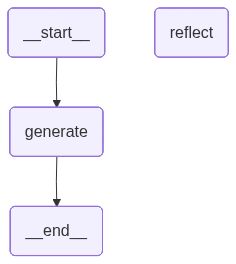

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__(<p>__start__</p>)
	generate(generate)
	reflect(reflect)
	__end__(<p>__end__</p>)
	__start__ --> generate;
	generate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [36]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))
print(workflow.get_graph().draw_mermaid())